In [23]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from bordas import det_roberts

In [24]:
# Carregar imagem
estrada_bgr = cv.imread('data/estrada.png')

In [25]:
# Implementação Opencv
estrada_manual = det_roberts(estrada_bgr)

# Implementação OpenCV (simulando Roberts com filter2D)
gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY).astype(np.float64)
kernel_gx = np.array([[1, 0], [0, -1]], dtype=np.float64)
kernel_gy = np.array([[0, 1], [-1, 0]], dtype=np.float64)

gx = cv.filter2D(gray, -1, kernel_gx)
gy = cv.filter2D(gray, -1, kernel_gy)
magnitude = np.sqrt(gx**2 + gy**2)
estrada_opencv = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

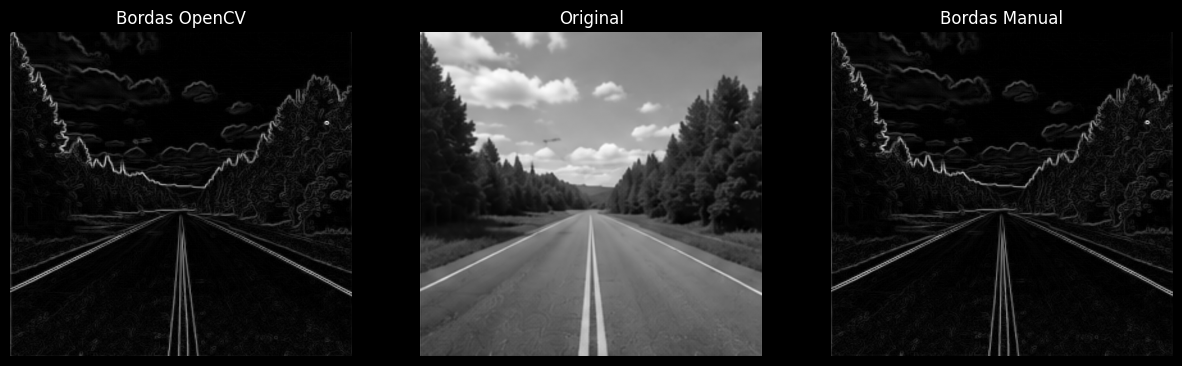

In [26]:
# Exibição em Grayscale

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Bordas OpenCV')
plt.imshow(estrada_opencv, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Original')
estrada_gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY)
plt.imshow(estrada_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Bordas Manual')
plt.imshow(estrada_manual, cmap='gray')
plt.axis('off')

plt.show()
